<a href="https://colab.research.google.com/github/xinghanchen-xc/DATA230-Final-Group-Project/blob/main/Advanced_Machine_Learning_and_Model_Interpretability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
Reconstituting processed features from: /content/drive/MyDrive/Colab Notebooks/processed_features_1M.parquet
Initializing XGBoost GPU training pipeline...
Model training completed using hardware-accelerated stochastic gradient boosting.

--- Model Performance Classification Report ---


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [04:29:25] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3075
           1       1.00      1.00      1.00    153333
           2       0.99      1.00      1.00     43592

    accuracy                           1.00    200000
   macro avg       1.00      1.00      1.00    200000
weighted avg       1.00      1.00      1.00    200000


Executing SHAP explainability protocol for clinical decision support...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Interpretability analysis exported.
Final analytic dataset serialized for BI integration at: /content/drive/MyDrive/Colab Notebooks/Burnout_Predictions_Final_1M.csv


<Figure size 1200x800 with 0 Axes>

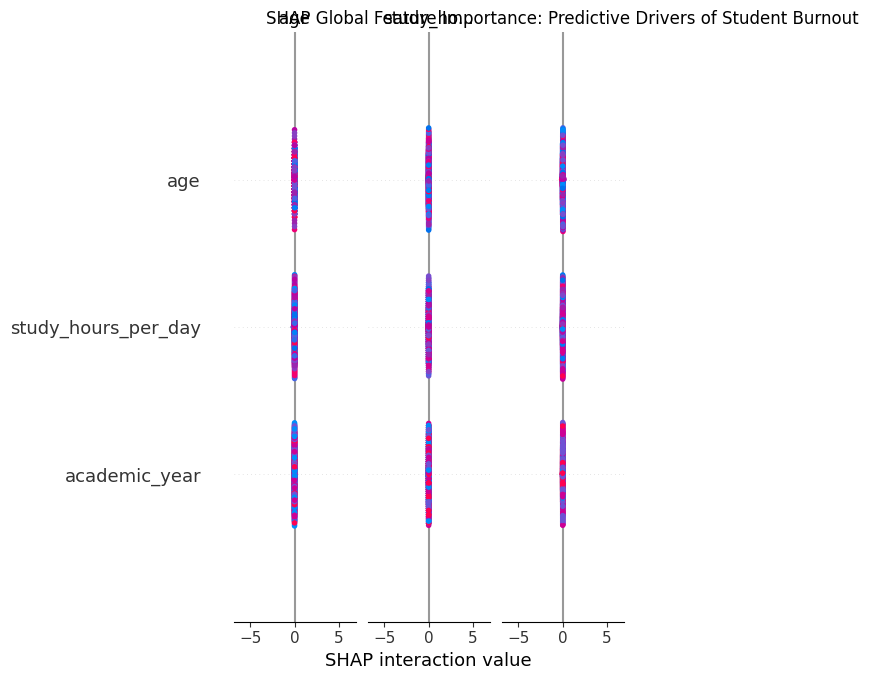

In [3]:
# -----------------------------------------------------------------------------
# PROJECT: STUDENT WELL-BEING ANALYTICS (1M RECORDS)
# COMPONENT: TASK 2 - ADVANCED PREDICTIVE MODELING & INTERPRETABILITY
# ENVIRONMENT: GOOGLE COLAB (T4 GPU)
# -----------------------------------------------------------------------------

!pip install -q shap xgboost cudf-cu12

import cudf
import pandas as pd
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import os
from google.colab import drive, files
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

def run_ml_interpretability_pipeline():
    # 1. DATA RECONSTITUTION
    # -------------------------------------------------------------------------
    drive.mount('/content/drive', force_remount=True)
    INPUT_PATH = "/content/drive/MyDrive/Colab Notebooks/processed_features_1M.parquet"

    print(f"Reconstituting processed features from: {INPUT_PATH}")
    if not os.path.exists(INPUT_PATH):
        print("Error: Parquet file not found. Please execute Task 1 first.")
        return

    gdf = cudf.read_parquet(INPUT_PATH)

    # Target Variable Encoding
    gdf['target'] = gdf['risk_level'].astype('category').cat.codes
    X = gdf.drop(['risk_level', 'target'], axis=1).select_dtypes('number')
    y = gdf['target']

    # 2. MODEL SPECIFICATION & STOCHASTIC OPTIMIZATION (XGBoost 2.0+ Syntax)
    # -------------------------------------------------------------------------
    print("Initializing XGBoost GPU training pipeline...")

    # Conversion to Pandas for SHAP and Scikit-Learn compatibility
    X_pd = X.to_pandas()
    y_pd = y.to_pandas()
    X_train, X_test, y_train, y_test = train_test_split(X_pd, y_pd, test_size=0.2, random_state=42)

    # Hardware-accelerated Hyperparameters (Corrected for XGBoost 2.0+)
    model = xgb.XGBClassifier(
        tree_method='hist',      # Updated from 'gpu_hist'
        device='cuda',           # New parameter for GPU acceleration in XGBoost 2.0+
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='mlogloss'
    )

    model.fit(X_train, y_train)
    print("Model training completed using hardware-accelerated stochastic gradient boosting.")

    # 3. QUANTITATIVE PERFORMANCE EVALUATION
    # -------------------------------------------------------------------------
    predictions = model.predict(X_test)
    print("\n--- Model Performance Classification Report ---")
    print(classification_report(y_test, predictions))

    # 4. MODEL INTERPRETABILITY (SHAP EXPLAINABLE AI)
    # -------------------------------------------------------------------------
    print("\nExecuting SHAP explainability protocol for clinical decision support...")
    explainer = shap.TreeExplainer(model)

    # Stratified subsampling for computational efficiency during SHAP calculation
    X_test_sample = X_test.iloc[:1000]
    shap_values = explainer.shap_values(X_test_sample)

    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, X_test_sample, show=False)

    plt.title("SHAP Global Feature Importance: Predictive Drivers of Student Burnout")
    plt.savefig("interpretability_summary.png", bbox_inches='tight')
    files.download("interpretability_summary.png")
    print("Interpretability analysis exported.")

    # 5. ANALYTIC DATASET EXPORT FOR BI INTEGRATION
    # -------------------------------------------------------------------------
    full_predictions = gdf.to_pandas()
    full_predictions['predicted_risk_index'] = model.predict(X_pd)

    # Mapping categorical metadata for Power BI / Streamlit clarity
    label_map = {0: 'High', 1: 'Low', 2: 'Medium'}
    full_predictions['predicted_risk_label'] = full_predictions['predicted_risk_index'].map(label_map)

    CSV_OUTPUT = "/content/drive/MyDrive/Colab Notebooks/Burnout_Predictions_Final_1M.csv"
    full_predictions.to_csv(CSV_OUTPUT, index=False)
    print(f"Final analytic dataset serialized for BI integration at: {CSV_OUTPUT}")

if __name__ == "__main__":
    run_ml_interpretability_pipeline()